## Module 3 Mini-Project: MNIST Digit Classifier

### The Task:
You will build a real "Deep Learning" model! We will use the famous MNIST dataset (a collection of 28x28 pixel images of handwritten numbers from 0 to 9). You will build a PyTorch model to look at these pixels and predict which number it is.

## Cell 1: Setup and Loading Data

100.0%
100.0%
100.0%
100.0%


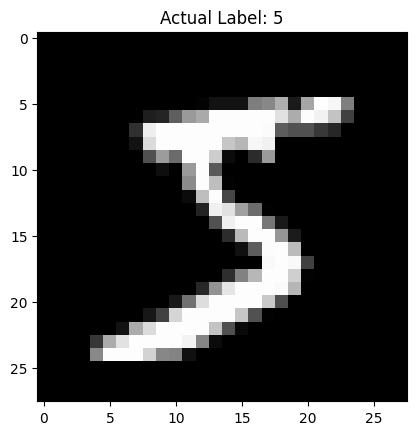

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 1. Download and load the dataset
# Transforms convert the image pixels into PyTorch Tensors
transform = transforms.ToTensor()

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# A DataLoader feeds the data to our model in small batches
train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)

# Let's look at one image
image, label = train_data[0]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Actual Label: {label}")
plt.show()

## Cell 2: Defining the Neural Network

In [2]:
# The images are 28x28 pixels. 28 * 28 = 784 total pixels (inputs)
# We want to predict numbers 0-9, so we need 10 outputs.

model = nn.Sequential(
    nn.Flatten(),                      # Flattens the 28x28 image into a 1D line of 784 pixels
    nn.Linear(784, 128),               # Hidden layer with 128 artificial neurons
    nn.ReLU(),                         # Activation function
    nn.Linear(128, 10)                 # Output layer with 10 classes (0 through 9)
)

# Define the Loss Function (CrossEntropy is standard for classification)
criterion = nn.CrossEntropyLoss()

# Define the Optimizer (Adam is a very popular variant of Gradient Descent)
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Cell 3: The Training Loop

In [3]:
# We will train the model for 1 "Epoch" (one full pass over the dataset)
print("Starting Training...")

for batch_idx, (images, labels) in enumerate(train_loader):
    # 1. Forward Pass: Make predictions
    predictions = model(images)
    
    # 2. Calculate the Error (Loss)
    loss = criterion(predictions, labels)
    
    # 3. Backward Pass: Calculate Gradients
    optimizer.zero_grad() # Clear old gradients
    loss.backward()       # Calculate new gradients
    
    # 4. Update Weights
    optimizer.step()      # Take a step down the mountain!
    
    if batch_idx % 200 == 0:
        print(f"Batch {batch_idx} completed. Current Loss: {loss.item():.4f}")

print("Training Complete!")

Starting Training...
Batch 0 completed. Current Loss: 2.3173
Batch 200 completed. Current Loss: 0.2507
Batch 400 completed. Current Loss: 0.1879
Batch 600 completed. Current Loss: 0.1322
Batch 800 completed. Current Loss: 0.1662
Training Complete!


## Cell 4: Testing the Model

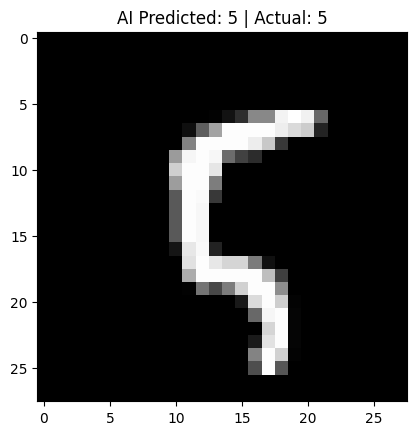

In [4]:
# Let's test it on a random image from the dataset
test_image, test_label = train_data[100]

# Model needs a batch dimension, so we add a temporary one using unsqueeze
with torch.no_grad(): # Turn off gradient tracking for testing (saves memory)
    raw_prediction = model(test_image.unsqueeze(0))
    # Get the index of the highest predicted value
    predicted_digit = torch.argmax(raw_prediction).item() 

plt.imshow(test_image.squeeze(), cmap="gray")
plt.title(f"AI Predicted: {predicted_digit} | Actual: {test_label}")
plt.show()